In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    # Walks up from the notebook's working directory until data/raw/gene_expression is found -- the same anchor notebook 01 uses.
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
RAW = ROOT / 'data' / 'raw'
GENE_EXPRESSION = RAW / 'gene_expression'
GENE_PROPERTIES = RAW / 'gene_properties'
NOMENCLATURE = RAW / 'nomenclature'
NON_GENE_EXPRESSION = RAW / 'non_gene_expression'
AUGMENTED = ROOT / 'data' / 'augmented'
print(f"Project root: {ROOT}")


Project root: D:\uob\final\az-team25


In [2]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv')
df17 = pd.read_csv(AUGMENTED / 'nomenclature' / '17_Model.csv')

legacy_ids = set(df9['DepMap_ID'].dropna())
modern_ids = set(df17['ModelID'].dropna())
spine_ids = sorted(legacy_ids | modern_ids)

spine = pd.DataFrame({'model_id': spine_ids})
spine = spine.merge(
    df9[['DepMap_ID', 'RRID', 'lineage', 'primary_disease', 'CCLE_Name']],
    left_on='model_id', right_on='DepMap_ID', how='left',
).drop(columns=['DepMap_ID']).rename(
    columns={'RRID': 'RRID_legacy', 'lineage': 'lineage_legacy', 'primary_disease': 'disease_legacy'}
)
spine = spine.merge(
    df17[['ModelID', 'RRID', 'OncotreeLineage', 'OncotreePrimaryDisease', 'CCLEName']],
    left_on='model_id', right_on='ModelID', how='left',
).drop(columns=['ModelID']).rename(
    columns={'RRID': 'RRID_modern', 'OncotreeLineage': 'lineage_modern', 'OncotreePrimaryDisease': 'disease_modern'}
)
spine['in_legacy'] = spine['model_id'].isin(legacy_ids)
spine['in_modern'] = spine['model_id'].isin(modern_ids)
assert spine['model_id'].is_unique, "model_id must be a clean primary key for the spine"

df7 = pd.read_csv(NOMENCLATURE / '7_cellosaurus.csv')
human_cancer = df7[
    df7['Species of origin'].str.contains('Homo sapiens', na=False)
    & (df7['Category'] == 'Cancer cell line')
]
human_cancer_accessions = set(human_cancer['Accession (CVCL_xxxx)'].dropna())

spine['RRID'] = spine['RRID_legacy'].combine_first(spine['RRID_modern'])
spine['passes_species_cancer_gate'] = spine['RRID'].isin(human_cancer_accessions)
gated_spine = spine[spine['passes_species_cancer_gate']].copy().reset_index(drop=True)
N = len(gated_spine)

gated_spine['lineage_canonical'] = gated_spine['lineage_modern'].combine_first(gated_spine['lineage_legacy'])

print(f"Rebuilt gated spine size: N = {N}")
print(f"Rebuilt lineage_canonical categories: {gated_spine['lineage_canonical'].nunique()}")
print(f"Rebuilt lineage_canonical missing: {gated_spine['lineage_canonical'].isna().sum()}")

# Sanity check against notebook 01's cited numbers -- stop here if this does not match, per the
# house rule that a downstream notebook never silently diverges from an upstream one.
assert N == 1874, f"Spine size {N} does not match notebook 01's cited N=1874"
assert gated_spine['lineage_canonical'].nunique() == 38, "lineage_canonical category count does not match notebook 01"
assert gated_spine['lineage_canonical'].isna().sum() == 0, "lineage_canonical should have 0 missing, per notebook 01"
print("\nMatches notebook 01's cited N=1,874, 38 lineage_canonical categories, 0 missing: CONFIRMED")


Rebuilt gated spine size: N = 1874
Rebuilt lineage_canonical categories: 38
Rebuilt lineage_canonical missing: 0

Matches notebook 01's cited N=1,874, 38 lineage_canonical categories, 0 missing: CONFIRMED


In [3]:
# RRID -> model_id lookup used by the two 3-hop bridges (HPA, GEO); one Cellosaurus accession can
# legitimately resolve to more than one ModelID (re-profiling), so both get bridged evidence.
rrid_to_models = gated_spine.dropna(subset=['RRID']).groupby('RRID')['model_id'].apply(set).to_dict()


def bridge_via_rrid(rrid_series: pd.Series) -> set:
    # Resolves a Series of Cellosaurus accessions to the set of gated spine model_ids they touch.
    out = set()
    for rrid in rrid_series.dropna():
        out |= rrid_to_models.get(rrid, set())
    return out


ccle_to_model = (
    gated_spine.dropna(subset=['CCLE_Name'])
    .drop_duplicates('CCLE_Name')
    .set_index('CCLE_Name')['model_id']
)


In [4]:
%%time
hpa_names = pd.read_csv(GENE_EXPRESSION / '1_4_hpa_rna_celline.tsv', sep='\t', usecols=['Cell line'])['Cell line'].unique()
df11 = pd.read_csv(NOMENCLATURE / '11_hpa_rna_celline_description.tsv', sep='\t', usecols=['Cell line', 'Cellosaurus ID'])
name_to_cvcl = df11.dropna(subset=['Cell line']).drop_duplicates('Cell line').set_index('Cell line')['Cellosaurus ID']
hpa_models = bridge_via_rrid(pd.Series(hpa_names).map(name_to_cvcl).dropna())

rna_profile_ids = set(pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', usecols=[0]).iloc[:, 0])
df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
df8_rna = df8[df8['Datatype'] == 'rna']
rna_models = set(df8_rna.loc[df8_rna['ProfileID'].isin(rna_profile_ids), 'ModelID'].dropna())

geo_header = pd.read_csv(GENE_EXPRESSION / '3_GEOexpression.txt', sep='\t', nrows=0).columns
gsm_cols = [c for c in geo_header if c.startswith('GSM')]
df10 = pd.read_csv(NOMENCLATURE / '10_GEOInfo.txt', sep='\t', usecols=['Geo_accession', 'Cellosaurus_ID'])
gsm_to_cvcl = df10.dropna(subset=['Cellosaurus_ID']).drop_duplicates('Geo_accession').set_index('Geo_accession')['Cellosaurus_ID']
geo_models = bridge_via_rrid(pd.Series(gsm_cols).map(gsm_to_cvcl).dropna())

mut_profiles = set(pd.read_csv(GENE_PROPERTIES / '6_OmicsSomaticMutationsProfile.csv', usecols=['ProfileID'], low_memory=False)['ProfileID'].dropna())
df8_dna = df8[df8['Datatype'].isin(['wes', 'wgs'])]
mut_models = set(df8_dna.loc[df8_dna['ProfileID'].isin(mut_profiles), 'ModelID'].dropna())
print("HPA/DepMap-RNA/GEO/mutations bridges rebuilt")


HPA/DepMap-RNA/GEO/mutations bridges rebuilt
CPU times: total: 43 s
Wall time: 44.3 s


In [5]:
prot_models = set(pd.read_csv(GENE_EXPRESSION / '4_Harmonized_MS_CCLE_Gygi_subsetted.csv', usecols=[0]).iloc[:, 0])

df5 = pd.read_csv(GENE_PROPERTIES / '5_OmicsFusionFilteredSupplementary.csv', usecols=['ModelID', 'IsDefaultEntryForModel'])
fusion_models = set(df5.loc[df5['IsDefaultEntryForModel'] == 'Yes', 'ModelID'].dropna())

df12 = pd.read_csv(NON_GENE_EXPRESSION / '12_CCLE_metabolomics_20190502.csv', usecols=['DepMap_ID', 'CCLE_ID'])
metab_direct = set(df12['DepMap_ID'].dropna())
missing_depmapid = df12[df12['DepMap_ID'].isna()]
metab_models = metab_direct | set(missing_depmapid['CCLE_ID'].map(ccle_to_model).dropna())

mirna_header = pd.read_csv(NON_GENE_EXPRESSION / '13_CCLE_miRNA_20181103.gct', sep='\t', skiprows=2, index_col=0, nrows=0).columns
mirna_ccle_ids = [c for c in mirna_header if c != 'Description']
mirna_models = set(pd.Series(mirna_ccle_ids).map(ccle_to_model).dropna())

df14 = pd.read_csv(NON_GENE_EXPRESSION / '14_OmicsGlobalSignatures.csv', usecols=['ModelID', 'IsDefaultEntryForModel'])
sig_models = set(df14.loc[df14['IsDefaultEntryForModel'] == 'Yes', 'ModelID'].dropna())

crispr_models = set(pd.read_csv(AUGMENTED / 'gene_properties' / '15_CRISPRGeneEffect.csv', usecols=[0]).iloc[:, 0])

df16 = pd.read_csv(AUGMENTED / 'gene_properties' / '16_OmicsCNGeneWGS.csv', usecols=['ModelID', 'IsDefaultEntryForModel'])
cn_models = set(df16.loc[df16['IsDefaultEntryForModel'] == 'Yes', 'ModelID'].dropna())

layer_model_sets = {
    'hpa_rna': hpa_models,
    'depmap_rna': rna_models,
    'geo_rna': geo_models,
    'proteomics': prot_models,
    'fusions': fusion_models,
    'mutations': mut_models,
    'metabolomics': metab_models,
    'mirna': mirna_models,
    'genome_signatures': sig_models,
    'crispr': crispr_models,
    'copy_number': cn_models,
}
for name, models in layer_model_sets.items():
    gated_spine[f'has_{name}'] = gated_spine['model_id'].isin(models)

layer_names = list(layer_model_sets.keys())
coverage_rows = []
for name in layer_names:
    n_covered = int(gated_spine[f'has_{name}'].sum())
    coverage_rows.append({'layer': name, 'models_covered': n_covered, 'coverage_pct_of_N': round(100 * n_covered / N, 1)})
layer_coverage = pd.DataFrame(coverage_rows)
print(layer_coverage.to_string(index=False))


            layer  models_covered  coverage_pct_of_N
          hpa_rna            1060               56.6
       depmap_rna            1383               73.8
          geo_rna             592               31.6
       proteomics             375               20.0
          fusions            1517               80.9
        mutations            1638               87.4
     metabolomics             908               48.5
            mirna             909               48.5
genome_signatures            1765               94.2
           crispr            1158               61.8
      copy_number            1052               56.1


In [6]:
# Sanity check against notebook 01's cited per-layer coverage (section 6l there) -- rounded to 1 dp.
expected_coverage = {
    'hpa_rna': 56.6, 'depmap_rna': 73.8, 'geo_rna': 31.6, 'proteomics': 20.0, 'fusions': 80.9,
    'mutations': 87.4, 'metabolomics': 48.5, 'mirna': 48.5, 'genome_signatures': 94.2,
    'crispr': 61.8, 'copy_number': 56.1,
}
rebuilt = dict(zip(layer_coverage['layer'], layer_coverage['coverage_pct_of_N']))
mismatches = {k: (rebuilt[k], v) for k, v in expected_coverage.items() if abs(rebuilt[k] - v) > 0.05}
assert not mismatches, f"Rebuilt coverage does not match notebook 01: {mismatches}"
print("Matches notebook 01's cited per-layer coverage percentages exactly: CONFIRMED")


Matches notebook 01's cited per-layer coverage percentages exactly: CONFIRMED


In [7]:
bool_cols = [f'has_{n}' for n in layer_names]
n_per_lineage = gated_spine['lineage_canonical'].value_counts()

lineage_layer_coverage = gated_spine.groupby('lineage_canonical')[bool_cols].mean().mul(100).round(1)
lineage_layer_coverage.columns = layer_names
lineage_layer_coverage = lineage_layer_coverage.loc[n_per_lineage.index]  # sort rows by lineage size, largest first

print(f"Table shape: {lineage_layer_coverage.shape[0]} lineages x {lineage_layer_coverage.shape[1]} layers")
lineage_layer_coverage


Table shape: 38 lineages x 11 layers


,hpa_rna,depmap_rna,geo_rna,proteomics,fusions,mutations,metabolomics,mirna,genome_signatures,crispr,copy_number
lineage_canonical,,,,,,,,,,,
Lung,77.0,76.2,40.1,30.2,81.3,89.3,67.5,66.3,93.3,49.6,59.5
Lymphoid,60.2,67.0,39.4,10.9,77.8,86.4,48.9,50.7,95.9,39.4,49.3
Skin,39.6,66.2,28.8,23.7,79.9,80.6,36.7,36.0,94.2,53.2,54.0
CNS/Brain,56.0,75.9,21.6,12.1,79.3,91.4,43.1,42.2,94.8,76.7,61.2
Bowel,62.5,80.2,53.1,31.2,88.5,83.3,58.3,59.4,92.7,65.6,58.3
Head and Neck,42.9,68.1,19.8,11.0,76.9,90.1,37.4,38.5,98.9,84.6,52.7
Breast,69.0,73.6,65.5,34.5,79.3,80.5,55.2,57.5,86.2,60.9,64.4
Esophagus/Stomach,77.4,84.5,40.5,33.3,86.9,97.6,75.0,73.8,100.0,79.8,58.3
Myeloid,68.3,74.4,39.0,19.5,89.0,78.0,61.0,58.5,95.1,52.4,67.1


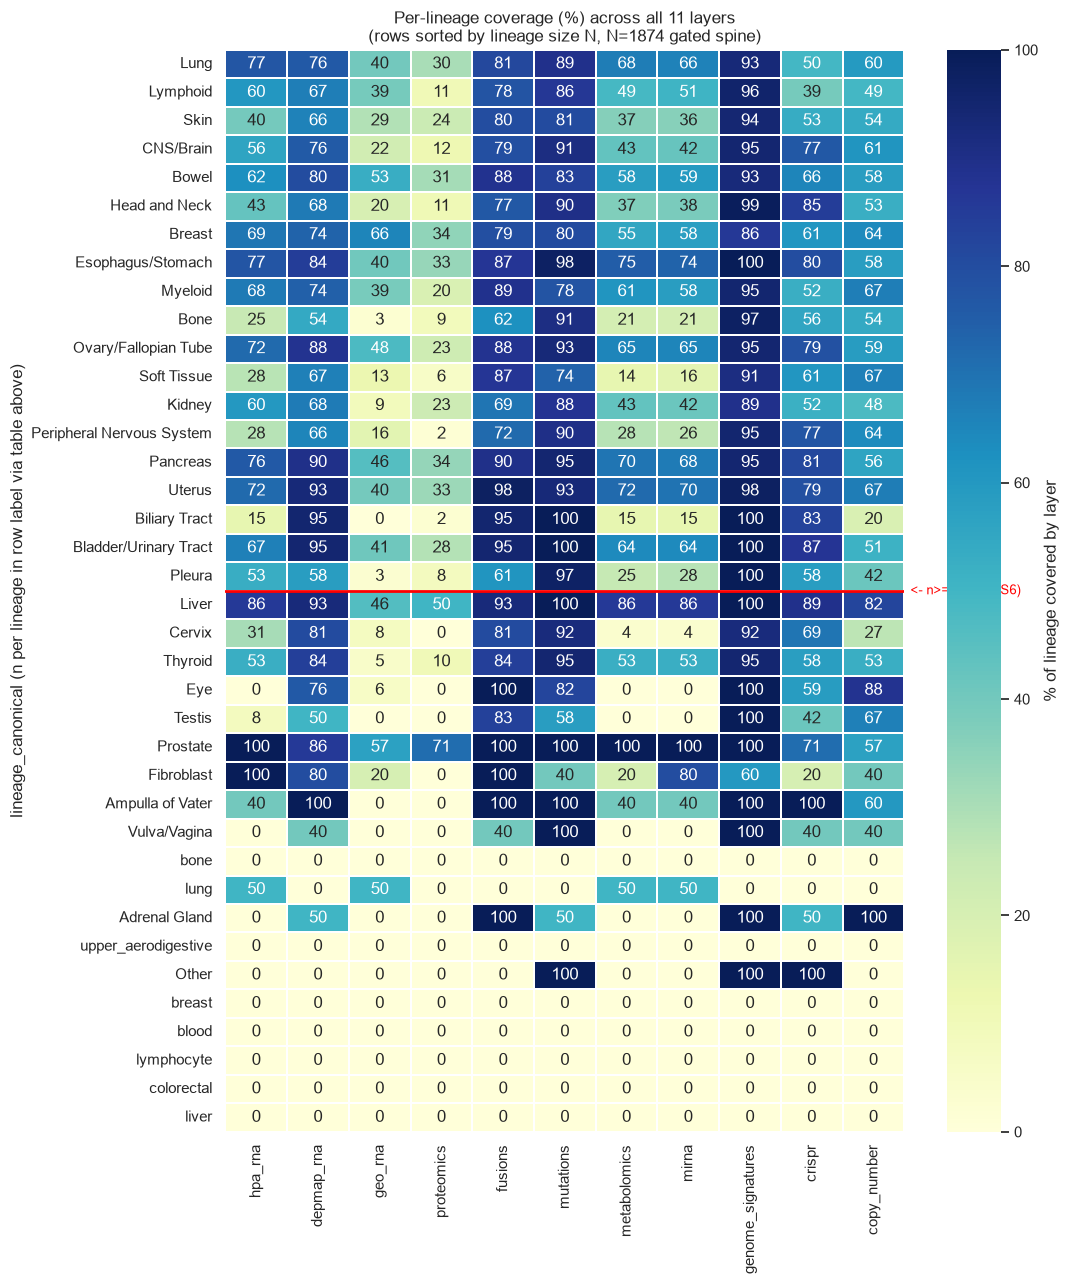

In [8]:
fig, ax = plt.subplots(figsize=(11, 13))
sns.heatmap(
    lineage_layer_coverage, annot=True, fmt='.0f', cmap='YlGnBu', vmin=0, vmax=100,
    cbar_kws={'label': '% of lineage covered by layer'}, ax=ax, linewidths=0.3, linecolor='white',
)
# n>=30 floor established in section 6 below -- drawn here too since the two sections read together.
floor_row = (n_per_lineage >= 30).sum()
ax.axhline(floor_row, color='red', linewidth=2)
ax.text(len(layer_names) + 0.1, floor_row, '<- n>=30 floor (S6)', va='center', color='red', fontsize=9)
ax.set_title(f'Per-lineage coverage (%) across all 11 layers\n(rows sorted by lineage size N, N=1874 gated spine)')
ax.set_ylabel('lineage_canonical (n per lineage in row label via table above)')
plt.tight_layout()
plt.show()


In [9]:
MIN_GROUP_SIZE = 30

small_lineages = n_per_lineage[n_per_lineage < MIN_GROUP_SIZE]
large_lineages = n_per_lineage[n_per_lineage >= MIN_GROUP_SIZE]

print(f"Lineages with n < {MIN_GROUP_SIZE} (row-level flag -- cannot support ANY layer's stratified claim):")
print(f"  {len(small_lineages)} of {len(n_per_lineage)} lineage_canonical categories")
print(f"  {small_lineages.sum()} of {N} models ({100*small_lineages.sum()/N:.1f}% of the gated spine)")
print()
print(f"Lineages with n >= {MIN_GROUP_SIZE} (large enough to support a stratified claim):")
print(f"  {len(large_lineages)} of {len(n_per_lineage)} lineage_canonical categories")
print(f"  {large_lineages.sum()} of {N} models ({100*large_lineages.sum()/N:.1f}% of the gated spine)")


Lineages with n < 30 (row-level flag -- cannot support ANY layer's stratified claim):
  19 of 38 lineage_canonical categories
  141 of 1874 models (7.5% of the gated spine)

Lineages with n >= 30 (large enough to support a stratified claim):
  19 of 38 lineage_canonical categories
  1733 of 1874 models (92.5% of the gated spine)


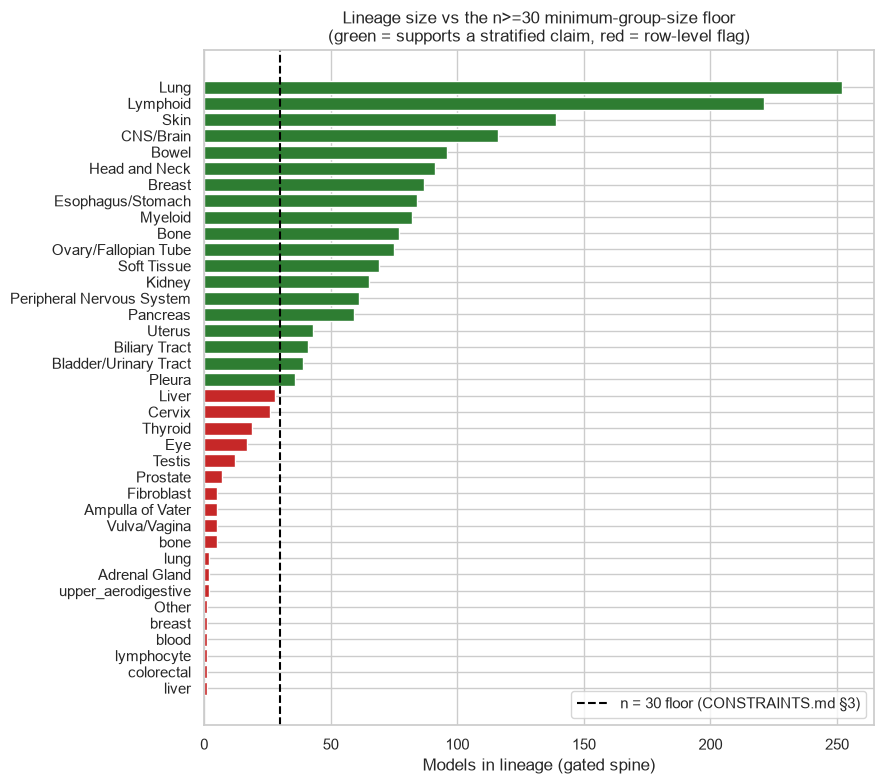

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#C62828' if n < MIN_GROUP_SIZE else '#2E7D32' for n in n_per_lineage.values]
ax.barh(n_per_lineage.index[::-1], n_per_lineage.values[::-1], color=colors[::-1])
ax.axvline(MIN_GROUP_SIZE, color='black', linestyle='--', label=f'n = {MIN_GROUP_SIZE} floor (CONSTRAINTS.md §3)')
ax.set_xlabel('Models in lineage (gated spine)')
ax.set_title('Lineage size vs the n>=30 minimum-group-size floor\n(green = supports a stratified claim, red = row-level flag)')
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
# Cell-level flag: for the large-enough lineages, which (lineage, layer) cells still rest on a
# small raw covered count even though the lineage itself clears the floor.
large_lineage_names = large_lineages.index.tolist()
covered_counts = gated_spine[gated_spine['lineage_canonical'].isin(large_lineage_names)].groupby('lineage_canonical')[bool_cols].sum()
covered_counts.columns = layer_names
covered_counts = covered_counts.loc[large_lineage_names]

cell_level_flags = covered_counts < MIN_GROUP_SIZE  # True where the RAW COVERED COUNT (not lineage size) is still under the floor
n_cell_flags = int(cell_level_flags.values.sum())
print(f"(lineage, layer) cells where the lineage clears n>=30 but the layer's OWN covered count within it does not: {n_cell_flags} of {cell_level_flags.size}")
print()
print("Worked example -- Peripheral Nervous System (n=61, clears the row-level floor):")
example = pd.DataFrame({
    'coverage_pct': lineage_layer_coverage.loc['Peripheral Nervous System'],
    'raw_covered_count': covered_counts.loc['Peripheral Nervous System'],
})
example['cell_flagged_small_n'] = example['raw_covered_count'] < MIN_GROUP_SIZE
print(example.to_string())


(lineage, layer) cells where the lineage clears n>=30 but the layer's OWN covered count within it does not: 53 of 209

Worked example -- Peripheral Nervous System (n=61, clears the row-level floor):
                   coverage_pct  raw_covered_count  cell_flagged_small_n
hpa_rna                    27.9                 17                  True
depmap_rna                 65.6                 40                 False
geo_rna                    16.4                 10                  True
proteomics                  1.6                  1                  True
fusions                    72.1                 44                 False
mutations                  90.2                 55                 False
metabolomics               27.9                 17                  True
mirna                      26.2                 16                  True
genome_signatures          95.1                 58                 False
crispr                     77.0                 47                 Fals

In [12]:
top3_by_N_share = 100 * n_per_lineage.head(3).sum() / N
print(f"Reference: top-3 lineages by N ({', '.join(n_per_lineage.head(3).index)}) = {top3_by_N_share:.1f}% of N")
print()

concentration_rows = []
for name in layer_names:
    covered = gated_spine[gated_spine[f'has_{name}']]
    total_covered = len(covered)
    top3 = covered['lineage_canonical'].value_counts().head(3)
    top3_share = 100 * top3.sum() / total_covered
    concentration_rows.append({
        'layer': name,
        'total_covered': total_covered,
        'top3_lineages': ', '.join(top3.index),
        'top3_share_pct': round(top3_share, 1),
        'observed_vs_expected_ratio': round(top3_share / top3_by_N_share, 2),
    })
concentration = pd.DataFrame(concentration_rows).sort_values('observed_vs_expected_ratio', ascending=False).reset_index(drop=True)
concentration


Reference: top-3 lineages by N (Lung, Lymphoid, Skin) = 32.7% of N



,layer,total_covered,top3_lineages,top3_share_pct,observed_vs_expected_ratio
0,geo_rna,592,"Lung, Lymphoid, Breast",41.4,1.27
1,mirna,909,"Lung, Lymphoid, Esophagus/Stomach",37.5,1.15
2,metabolomics,908,"Lung, Lymphoid, Esophagus/Stomach",37.6,1.15
3,proteomics,375,"Lung, Skin, Bowel",37.1,1.14
4,hpa_rna,1060,"Lung, Lymphoid, CNS/Brain",37.0,1.13
5,genome_signatures,1765,"Lung, Lymphoid, Skin",32.7,1.00
6,mutations,1638,"Lung, Lymphoid, Skin",32.2,0.99
7,fusions,1517,"Lung, Lymphoid, Skin",32.2,0.99
8,copy_number,1052,"Lung, Lymphoid, Skin",31.7,0.97
9,depmap_rna,1383,"Lung, Lymphoid, Skin",31.2,0.96


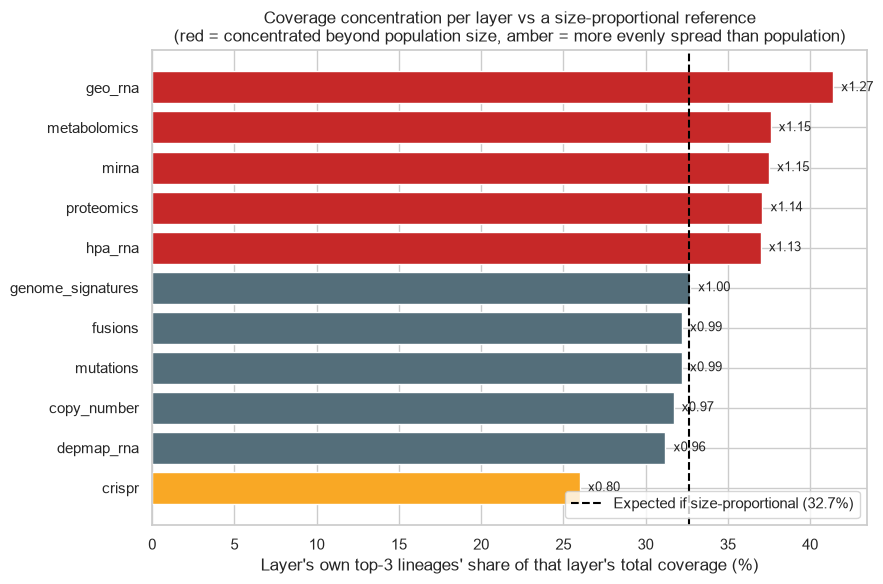

Layers flagged lineage-biased (top-3 concentration >=10% above the size-proportional reference):
       layer  top3_share_pct  observed_vs_expected_ratio
     geo_rna            41.4                        1.27
       mirna            37.5                        1.15
metabolomics            37.6                        1.15
  proteomics            37.1                        1.14
     hpa_rna            37.0                        1.13


In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = concentration.sort_values('top3_share_pct')
colors = ['#C62828' if r >= 1.10 else ('#F9A825' if r <= 0.85 else '#546E7A') for r in plot_df['observed_vs_expected_ratio']]
ax.barh(plot_df['layer'], plot_df['top3_share_pct'], color=colors)
ax.axvline(top3_by_N_share, color='black', linestyle='--', label=f'Expected if size-proportional ({top3_by_N_share:.1f}%)')
for i, (pct, ratio) in enumerate(zip(plot_df['top3_share_pct'], plot_df['observed_vs_expected_ratio'])):
    ax.text(pct + 0.5, i, f'x{ratio:.2f}', va='center', fontsize=9)
ax.set_xlabel("Layer's own top-3 lineages' share of that layer's total coverage (%)")
ax.set_title('Coverage concentration per layer vs a size-proportional reference\n(red = concentrated beyond population size, amber = more evenly spread than population)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

biased_layers = concentration[concentration['observed_vs_expected_ratio'] >= 1.10].sort_values('observed_vs_expected_ratio', ascending=False)
print("Layers flagged lineage-biased (top-3 concentration >=10% above the size-proportional reference):")
print(biased_layers[['layer', 'top3_share_pct', 'observed_vs_expected_ratio']].to_string(index=False))


In [14]:
# Per-lineage detail behind the aggregated top-3 share above -- which individual lineage, within
# each layer's top-3, is overrepresented the most relative to its own share of N.
detail_rows = []
for name in layer_names:
    covered = gated_spine[gated_spine[f'has_{name}']]
    total_covered = len(covered)
    top3 = covered['lineage_canonical'].value_counts().head(3)
    for lin, cnt in top3.items():
        expected_share = 100 * n_per_lineage[lin] / N
        observed_share = 100 * cnt / total_covered
        detail_rows.append({
            'layer': name, 'lineage': lin, 'covered_count': int(cnt),
            'observed_share_pct': round(observed_share, 1), 'expected_share_pct': round(expected_share, 1),
            'ratio': round(observed_share / expected_share, 2) if expected_share else np.nan,
        })
concentration_detail = pd.DataFrame(detail_rows)
print("Single largest individual lineage-level overrepresentation found in any layer's top-3:")
print(concentration_detail.sort_values('ratio', ascending=False).head(5).to_string(index=False))


Single largest individual lineage-level overrepresentation found in any layer's top-3:
       layer           lineage  covered_count  observed_share_pct  expected_share_pct  ratio
     geo_rna            Breast             57                 9.6                 4.6   2.07
  proteomics             Bowel             30                 8.0                 5.1   1.56
metabolomics Esophagus/Stomach             63                 6.9                 4.5   1.55
       mirna Esophagus/Stomach             62                 6.8                 4.5   1.52
  proteomics              Lung             76                20.3                13.4   1.51


In [15]:
print("=== Pattern A: large AND well-covered across nearly every layer (systematically privileged) ===")
for lin in ['Esophagus/Stomach', 'Pancreas', 'Uterus']:
    row = lineage_layer_coverage.loc[lin]
    print(f"{lin} (n={n_per_lineage[lin]}): min={row.min():.1f}%, median={row.median():.1f}%, max={row.max():.1f}% across the 11 layers")

print()
print("=== Pattern B: large enough to clear the floor, but genuinely gapped in specific layers ===")
for lin, layer in [('Bone', 'hpa_rna'), ('Soft Tissue', 'proteomics'), ('Peripheral Nervous System', 'proteomics')]:
    print(f"{lin} (n={n_per_lineage[lin]}): {layer} coverage = {lineage_layer_coverage.loc[lin, layer]:.1f}% "
          f"({int(covered_counts.loc[lin, layer]) if lin in covered_counts.index else int(gated_spine[gated_spine.lineage_canonical==lin][f'has_{layer}'].sum())} raw covered models)")

print()
print("=== Pattern C: small lineages that look misleadingly complete (below the n>=30 floor) ===")
for lin in ['Liver', 'Prostate', 'Ampulla of Vater']:
    row = lineage_layer_coverage.loc[lin]
    print(f"{lin} (n={n_per_lineage[lin]}, BELOW the n>=30 floor): min={row.min():.1f}%, median={row.median():.1f}%, max={row.max():.1f}% across the 11 layers")


=== Pattern A: large AND well-covered across nearly every layer (systematically privileged) ===
Esophagus/Stomach (n=84): min=33.3%, median=77.4%, max=100.0% across the 11 layers
Pancreas (n=59): min=33.9%, median=76.3%, max=94.9% across the 11 layers
Uterus (n=43): min=32.6%, median=72.1%, max=97.7% across the 11 layers

=== Pattern B: large enough to clear the floor, but genuinely gapped in specific layers ===
Bone (n=77): hpa_rna coverage = 24.7% (19 raw covered models)
Soft Tissue (n=69): proteomics coverage = 5.8% (4 raw covered models)
Peripheral Nervous System (n=61): proteomics coverage = 1.6% (1 raw covered models)

=== Pattern C: small lineages that look misleadingly complete (below the n>=30 floor) ===
Liver (n=28, BELOW the n>=30 floor): min=46.4%, median=85.7%, max=100.0% across the 11 layers
Prostate (n=7, BELOW the n>=30 floor): min=57.1%, median=100.0%, max=100.0% across the 11 layers
Ampulla of Vater (n=5, BELOW the n>=30 floor): min=0.0%, median=60.0%, max=100.0% acro

In [16]:
print("=== The eight all-lowercase lineage_canonical categories: who are they? ===")
legacy_only = gated_spine[~gated_spine['in_modern']]
print(f"Gated-spine models present ONLY in the legacy schema (file 9, absent from file 17): {len(legacy_only)}")
print(legacy_only['lineage_canonical'].value_counts().to_string())
print()
lowercase_lineages = [l for l in n_per_lineage.index if l.islower()]
all_legacy_only = gated_spine[gated_spine['lineage_canonical'].isin(lowercase_lineages)]['in_modern'].eq(False).all()
print(f"Every model in one of these {len(lowercase_lineages)} lowercase lineage_canonical categories is legacy-only: {all_legacy_only}")
print()
print("Their coverage across all 11 layers (all effectively 0%):")
print(lineage_layer_coverage.loc[lowercase_lineages])


=== The eight all-lowercase lineage_canonical categories: who are they? ===
Gated-spine models present ONLY in the legacy schema (file 9, absent from file 17): 14
lineage_canonical
bone                   5
lung                   2
upper_aerodigestive    2
breast                 1
blood                  1
lymphocyte             1
colorectal             1
liver                  1

Every model in one of these 8 lowercase lineage_canonical categories is legacy-only: True

Their coverage across all 11 layers (all effectively 0%):
                     hpa_rna  depmap_rna  geo_rna  proteomics  fusions  mutations  metabolomics  mirna  genome_signatures  crispr  \
lineage_canonical                                                                                                                   
bone                     0.0         0.0      0.0         0.0      0.0        0.0           0.0    0.0                0.0     0.0   
lung                    50.0         0.0     50.0         0.0      0.0

In [17]:
print(f"MINIMUM GROUP SIZE ADOPTED: n >= {MIN_GROUP_SIZE} (docs/plan/CONSTRAINTS.md §3)")
print(f"Lineages below floor: {len(small_lineages)} of 38 ({small_lineages.sum()} models, {100*small_lineages.sum()/N:.1f}% of N)")
print(f"Lineages at/above floor: {len(large_lineages)} of 38 ({large_lineages.sum()} models, {100*large_lineages.sum()/N:.1f}% of N)")
print()
print("Layers flagged lineage-biased (A2 warning candidates):")
print(biased_layers[['layer', 'top3_share_pct', 'observed_vs_expected_ratio']].to_string(index=False))
print()
print("Reference lineage-stratified table (lineage_layer_coverage) is available for notebooks 03/04 to cite.")


MINIMUM GROUP SIZE ADOPTED: n >= 30 (docs/plan/CONSTRAINTS.md §3)
Lineages below floor: 19 of 38 (141 models, 7.5% of N)
Lineages at/above floor: 19 of 38 (1733 models, 92.5% of N)

Layers flagged lineage-biased (A2 warning candidates):


       layer  top3_share_pct  observed_vs_expected_ratio
     geo_rna            41.4                        1.27
       mirna            37.5                        1.15
metabolomics            37.6                        1.15
  proteomics            37.1                        1.14
     hpa_rna            37.0                        1.13

Reference lineage-stratified table (lineage_layer_coverage) is available for notebooks 03/04 to cite.
